In [89]:
# ============================================================
# PHASE 11 — SUPERVISED 5% BASELINE
# COMPLETE EXPERIMENT SETUP
# ============================================================

from pathlib import Path
import random
import sys
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.optim import AdamW


# ============================================================
# PROJECT ROOT
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


# ============================================================
# PROJECT MODULES
# ============================================================

from src.cervical_ssl.config import (
    DATA_ROOT,
    PROCESSED_ROOT,
    SPLITS_ROOT,
    RESULTS_ROOT,
    CHECKPOINT_ROOT,
    BACKBONE,
    NUM_CLASSES,
    BATCH_SIZE,
    NUM_WORKERS,
    PIN_MEMORY,
    LEARNING_RATE,
    WEIGHT_DECAY,
    RANDOM_SEED,
)

from src.cervical_ssl.models import create_model

from src.cervical_ssl.datasets import (
    CervicalDataset,
    create_dataloader,
)

from src.cervical_ssl.transforms import (
    get_train_transform,
    get_val_transform,
)

from src.cervical_ssl.training import train_model

from src.cervical_ssl.evaluation import (
    evaluate_model,
    predict_model,
)

from src.cervical_ssl.experiment import (
    build_experiment_id,
    create_experiment_dirs,
)


# ============================================================
# EXPERIMENT DEFINITION
# ============================================================

SOURCE_DATASET = "cric"
METHOD = "supervised"

# Human-readable percentage used in experiment ID
LABEL_FRACTION = 5

# Actual fraction used for sampling
LABEL_FRACTION_RATIO = LABEL_FRACTION / 100.0


# ============================================================
# EXPERIMENT ID
# ============================================================

EXPERIMENT_ID = build_experiment_id(
    source_dataset=SOURCE_DATASET,
    method=METHOD,
    label_fraction=LABEL_FRACTION,
    backbone=BACKBONE,
    seed=RANDOM_SEED,
)


# ============================================================
# EXPERIMENT DIRECTORIES
# ============================================================

EXPERIMENT_DIRS = create_experiment_dirs(
    PROJECT_ROOT,
    EXPERIMENT_ID,
)

RESULTS_DIR = EXPERIMENT_DIRS["results"]
CHECKPOINT_DIR = EXPERIMENT_DIRS["checkpoints"]
CURVES_DIR = EXPERIMENT_DIRS["curves"]


# ============================================================
# EXPERIMENT FILE PATHS
# ============================================================

LABELED_SUBSET_PATH = (
    RESULTS_DIR / "labeled_subset.csv"
)

TRAINING_HISTORY_CSV = (
    RESULTS_DIR / "training_history.csv"
)

TRAINING_HISTORY_PKL = (
    RESULTS_DIR / "training_history.pkl"
)

TEST_RESULTS_CSV = (
    RESULTS_DIR / "test_results.csv"
)

TEST_RESULTS_PKL = (
    RESULTS_DIR / "test_results.pkl"
)

TEST_PREDICTIONS_CSV = (
    RESULTS_DIR / "test_predictions.csv"
)

EXPERIMENT_CONFIG_JSON = (
    RESULTS_DIR / "experiment_config.json"
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "best_model.pt"
)


# ============================================================
# PLOT PATHS
# ============================================================

LOSS_CURVE_PATH = (
    CURVES_DIR / "loss_curve.png"
)

ACCURACY_CURVE_PATH = (
    CURVES_DIR / "accuracy_curve.png"
)

MACRO_F1_CURVE_PATH = (
    CURVES_DIR / "macro_f1_curve.png"
)

SENSITIVITY_CURVE_PATH = (
    CURVES_DIR / "sensitivity_curve.png"
)

SPECIFICITY_CURVE_PATH = (
    CURVES_DIR / "specificity_curve.png"
)

CONFUSION_MATRIX_PATH = (
    CURVES_DIR / "confusion_matrix.png"
)

ROC_CURVE_PATH = (
    CURVES_DIR / "roc_curve.png"
)


# ============================================================
# TRAINING CONFIGURATION
# ============================================================

PHASE_EPOCHS = 50

EARLY_STOPPING_PATIENCE = 8

SELECTION_METRIC = "macro_f1"


# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# DATASET PATHS
# ============================================================

CRIC_MANIFEST = (
    PROCESSED_ROOT /
    "cric_learning_units.csv"
)

CRIC_SPLITS = (
    SPLITS_ROOT /
    "cric_splits.csv"
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("PHASE 11 — SUPERVISED 5% BASELINE")
print("=" * 60)

print("Experiment ID:", EXPERIMENT_ID)
print("Source dataset:", SOURCE_DATASET)
print("Method:", METHOD)
print("Backbone:", BACKBONE)

print(
    "Label fraction:",
    f"{LABEL_FRACTION}%"
)

print(
    "Label fraction ratio:",
    LABEL_FRACTION_RATIO
)

print("Random seed:", RANDOM_SEED)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("\nCRIC manifest:")
print(CRIC_MANIFEST)

print("\nCRIC splits:")
print(CRIC_SPLITS)

print("\nExperiment results:")
print(RESULTS_DIR)

print("\nExperiment checkpoint:")
print(BEST_CHECKPOINT_PATH)

print("\nExperiment curves:")
print(CURVES_DIR)

print("\n=== PHASE 11 SETUP COMPLETE ===")

Project root: c:\Users\nanda\Documents\cervical-semi-sl
PHASE 11 — SUPERVISED 5% BASELINE
Experiment ID: cric_supervised_5pct_densenet121_seed42
Source dataset: cric
Method: supervised
Backbone: densenet121
Label fraction: 5%
Label fraction ratio: 0.05
Random seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU

CRIC manifest:
C:\Users\nanda\Documents\cervical-semi-sl\data\processed\cric_learning_units.csv

CRIC splits:
C:\Users\nanda\Documents\cervical-semi-sl\data\splits\cric_splits.csv

Experiment results:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42

Experiment checkpoint:
c:\Users\nanda\Documents\cervical-semi-sl\data\checkpoints\experiments\cric_supervised_5pct_densenet121_seed42\best_model.pt

Experiment curves:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves

=== PHASE 11 SETUP COMPLETE ===


In [90]:
import importlib
import src.cervical_ssl.config as config

importlib.reload(config)

from src.cervical_ssl.config import (
    DATA_ROOT,
    PROCESSED_ROOT,
    SPLITS_ROOT,
    RESULTS_ROOT,
    CHECKPOINT_ROOT,
    BACKBONE,
    NUM_CLASSES,
    BATCH_SIZE,
    NUM_WORKERS,
    PIN_MEMORY,
    LEARNING_RATE,
    WEIGHT_DECAY,
    RANDOM_SEED,
)

print("WEIGHT_DECAY:", WEIGHT_DECAY)
print("LEARNING_RATE:", LEARNING_RATE)

WEIGHT_DECAY: 1e-05
LEARNING_RATE: 0.0001


In [91]:
# ============================================================
# PHASE 11 — STEP 2
# VERIFY FROZEN CRIC SPLIT + CREATE FIXED 5% SUBSET
# ============================================================


# ------------------------------------------------------------
# Load CRIC manifest and frozen split
# ------------------------------------------------------------

cric_manifest = pd.read_csv(
    CRIC_MANIFEST
)

cric_splits = pd.read_csv(
    CRIC_SPLITS
)

print(
    "CRIC manifest shape:",
    cric_manifest.shape
)

print(
    "CRIC split shape:",
    cric_splits.shape
)

print("\nManifest columns:")
print(
    cric_manifest.columns.tolist()
)

print("\nSplit columns:")
print(
    cric_splits.columns.tolist()
)


# ------------------------------------------------------------
# Verify frozen split counts
# ------------------------------------------------------------

split_counts = (
    cric_splits["split"]
    .value_counts()
    .sort_index()
)

print("\nFrozen split counts:")
print(split_counts)


expected_split_counts = {
    "train": 8274,
    "val": 1539,
    "test": 1721,
}

assert split_counts.to_dict() == expected_split_counts, (
    f"Unexpected split counts: "
    f"{split_counts.to_dict()}"
)

print(
    "\n✓ Frozen split counts match Phase 8."
)


# ------------------------------------------------------------
# Verify label distribution
# ------------------------------------------------------------

split_label_counts = (
    cric_splits
    .groupby(
        ["split", "binary_label"]
    )
    .size()
    .unstack(fill_value=0)
)

print("\nLabel distribution by split:")
print(split_label_counts)


# ------------------------------------------------------------
# Extract frozen training pool
# ------------------------------------------------------------

train_pool = (
    cric_splits[
        cric_splits["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "\nTraining pool size:",
    len(train_pool)
)


# ------------------------------------------------------------
# Calculate exact 5% labeled subset
# ------------------------------------------------------------

labeled_count = int(
    round(
        len(train_pool)
        * LABEL_FRACTION_RATIO
    )
)

print(
    f"\n{LABEL_FRACTION}% labeled subset size: "
    f"{labeled_count} / {len(train_pool)}"
)


# ------------------------------------------------------------
# Create deterministic labeled subset
# ------------------------------------------------------------

labeled_subset = (
    train_pool
    .sample(
        n=labeled_count,
        random_state=RANDOM_SEED,
    )
    .sort_index()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Verify subset
# ------------------------------------------------------------

assert (
    labeled_subset["split"] == "train"
).all()

assert (
    len(labeled_subset)
    == labeled_count
)

assert not labeled_subset.duplicated().any()


# ------------------------------------------------------------
# Verify no learning units outside frozen train pool
# ------------------------------------------------------------

train_unit_ids = set(
    train_pool.index
)

assert len(labeled_subset) == labeled_count


# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

subset_label_counts = (
    labeled_subset["binary_label"]
    .value_counts()
    .sort_index()
)

print(
    f"\n{LABEL_FRACTION}% labeled subset "
    "label distribution:"
)

print(subset_label_counts)


# ------------------------------------------------------------
# Save fixed subset
# ------------------------------------------------------------

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

labeled_subset.to_csv(
    LABELED_SUBSET_PATH,
    index=False,
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print(
    "\nSaved fixed labeled subset:"
)

print(LABELED_SUBSET_PATH)

print("\nFirst 5 selected learning units:")

display(
    labeled_subset.head()
)

print(
    "\n=== PHASE 11 STEP 2 COMPLETE ==="
)

CRIC manifest shape: (11534, 9)
CRIC split shape: (11534, 10)

Manifest columns:
['dataset', 'image_filename', 'cell_id', 'x_pixel', 'y_pixel', 'class_bethesda', 'binary_label', 'crop_path', 'crop_valid']

Split columns:
['dataset', 'image_filename', 'cell_id', 'x_pixel', 'y_pixel', 'class_bethesda', 'binary_label', 'crop_path', 'crop_valid', 'split']

Frozen split counts:
split
test     1721
train    8274
val      1539
Name: count, dtype: int64

✓ Frozen split counts match Phase 8.

Label distribution by split:
binary_label     0     1
split                   
test          1108   613
train         4736  3538
val            935   604

Training pool size: 8274

5% labeled subset size: 414 / 8274

5% labeled subset label distribution:
binary_label
0    249
1    165
Name: count, dtype: int64

Saved fixed labeled subset:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\labeled_subset.csv

First 5 selected learning units:


,dataset,image_filename,cell_id,x_pixel,y_pixel,class_bethesda,binary_label,crop_path,crop_valid,split
0,CRIC,9ae8a4edde40219bad6303cebc672ee4.png,24,219,160,LSIL,1,data\processed\cric_crops\9ae8a4edde40219bad63...,True,train
1,CRIC,9ae8a4edde40219bad6303cebc672ee4.png,34,973,556,ASC-H,1,data\processed\cric_crops\9ae8a4edde40219bad63...,True,train
2,CRIC,dc2df7c3f88649ded343b13b9486cddf.png,66,541,127,SCC,1,data\processed\cric_crops\dc2df7c3f88649ded343...,True,train
3,CRIC,0cc6e576dac3046d279bba515e10a7a9.png,94,1024,591,SCC,1,data\processed\cric_crops\0cc6e576dac3046d279b...,True,train
4,CRIC,0cc6e576dac3046d279bba515e10a7a9.png,102,391,865,SCC,1,data\processed\cric_crops\0cc6e576dac3046d279b...,True,train



=== PHASE 11 STEP 2 COMPLETE ===


In [92]:
# ============================================================
# PHASE 11 — STEP 3
# BUILD 5% SUPERVISED TRAIN / VALIDATION LOADERS
# ============================================================


# ------------------------------------------------------------
# Transforms
# ------------------------------------------------------------

train_transform = get_train_transform(
    BACKBONE
)

val_transform = get_val_transform(
    BACKBONE
)


# ------------------------------------------------------------
# Training dataset
# ------------------------------------------------------------

train_dataset = CervicalDataset(
    manifest=labeled_subset,
    transform=train_transform,
    project_root=PROJECT_ROOT,
)


# ------------------------------------------------------------
# Complete frozen validation dataset
# ------------------------------------------------------------

val_data = (
    cric_splits[
        cric_splits["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)

val_dataset = CervicalDataset(
    manifest=val_data,
    transform=val_transform,
    project_root=PROJECT_ROOT,
)


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 60)
print("PHASE 11 — DATA LOADER VERIFICATION")
print("=" * 60)

print("Backbone:", BACKBONE)

print("\nTraining:")
print(
    "Dataset size:",
    len(train_dataset)
)

print(
    "Batches:",
    len(train_loader)
)

print("\nValidation:")
print(
    "Dataset size:",
    len(val_dataset)
)

print(
    "Batches:",
    len(val_loader)
)


# ------------------------------------------------------------
# Inspect batches
# ------------------------------------------------------------

train_images, train_labels = next(
    iter(train_loader)
)

val_images, val_labels = next(
    iter(val_loader)
)


print("\nTraining batch:")

print(
    "Images:",
    train_images.shape
)

print(
    "Labels:",
    train_labels.shape
)

print(
    "Image dtype:",
    train_images.dtype
)

print(
    "Label dtype:",
    train_labels.dtype
)


print("\nValidation batch:")

print(
    "Images:",
    val_images.shape
)

print(
    "Labels:",
    val_labels.shape
)

print(
    "Image dtype:",
    val_images.dtype
)

print(
    "Label dtype:",
    val_labels.dtype
)


print(
    "\n=== PHASE 11 STEP 3 COMPLETE ==="
)

PHASE 11 — DATA LOADER VERIFICATION
Backbone: densenet121

Training:
Dataset size: 414
Batches: 13

Validation:
Dataset size: 1539
Batches: 49

Training batch:
Images: torch.Size([32, 3, 128, 128])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64

Validation batch:
Images: torch.Size([32, 3, 128, 128])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64

=== PHASE 11 STEP 3 COMPLETE ===


In [93]:
# ============================================================
# PHASE 11 — STEP 4
# CREATE MODEL + TRAINING CONFIGURATION
# ============================================================


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = create_model(
    backbone=BACKBONE,
    num_classes=NUM_CLASSES,
)

model = model.to(DEVICE)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

PHASE_EPOCHS = 50

EARLY_STOPPING_PATIENCE = 8

SELECTION_METRIC = "macro_f1"


# ------------------------------------------------------------
# Checkpoint path
# ------------------------------------------------------------

CHECKPOINT_PATH = BEST_CHECKPOINT_PATH


# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 60)
print("PHASE 11 — MODEL CONFIGURATION")
print("=" * 60)

print("Experiment ID:", EXPERIMENT_ID)
print("Backbone:", BACKBONE)
print("Number of classes:", NUM_CLASSES)
print("Input size:", 128)

print("\nTraining configuration:")

print(
    "Label fraction:",
    f"{LABEL_FRACTION}%"
)

print(
    "Labeled training units:",
    len(train_dataset)
)

print(
    "Validation units:",
    len(val_dataset)
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Weight decay:",
    WEIGHT_DECAY
)

print(
    "Optimizer: AdamW"
)

print(
    "Loss: CrossEntropyLoss"
)

print(
    "Maximum epochs:",
    PHASE_EPOCHS
)

print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Model selection metric:",
    SELECTION_METRIC
)


print("\nModel:")
print(model.classifier)

print("\nDevice:")
print(DEVICE)

print("\nCheckpoint:")
print(CHECKPOINT_PATH)

print(
    "\n=== PHASE 11 STEP 4 COMPLETE ==="
)

PHASE 11 — MODEL CONFIGURATION
Experiment ID: cric_supervised_5pct_densenet121_seed42
Backbone: densenet121
Number of classes: 2
Input size: 128

Training configuration:
Label fraction: 5%
Labeled training units: 414
Validation units: 1539
Batch size: 32
Learning rate: 0.0001
Weight decay: 1e-05
Optimizer: AdamW
Loss: CrossEntropyLoss
Maximum epochs: 50
Early stopping patience: 8
Model selection metric: macro_f1

Model:
Linear(in_features=1024, out_features=2, bias=True)

Device:
cuda

Checkpoint:
c:\Users\nanda\Documents\cervical-semi-sl\data\checkpoints\experiments\cric_supervised_5pct_densenet121_seed42\best_model.pt

=== PHASE 11 STEP 4 COMPLETE ===


In [94]:
# ============================================================
# PHASE 11 — RELOAD TRAINING + EVALUATION MODULES
# ============================================================

import importlib

import src.cervical_ssl.training as training_module
import src.cervical_ssl.evaluation as evaluation_module


# Reload modified modules
importlib.reload(training_module)
importlib.reload(evaluation_module)


# Refresh functions
train_model = training_module.train_model

evaluate_model = evaluation_module.evaluate_model

predict_model = evaluation_module.predict_model


print("Training module reloaded.")
print("Evaluation module reloaded.")
print("train_model:", train_model)
print("evaluate_model:", evaluate_model)
print("predict_model:", predict_model)

print("\n=== MODULE RELOAD COMPLETE ===")

Training module reloaded.
Evaluation module reloaded.
train_model: <function train_model at 0x000001BF6A312E50>
evaluate_model: <function evaluate_model at 0x000001BF6A259900>
predict_model: <function predict_model at 0x000001BF6A258BF0>

=== MODULE RELOAD COMPLETE ===


In [95]:
# ============================================================
# PHASE 11 — STEP 5
# ACTUAL SUPERVISED 5% BASELINE TRAINING
# ============================================================

print("=" * 60)
print("PHASE 11 — SUPERVISED 5% BASELINE TRAINING")
print("=" * 60)

print("Experiment ID:", EXPERIMENT_ID)
print("Backbone:", BACKBONE)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Maximum epochs:", PHASE_EPOCHS)
print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE,
)
print(
    "Selection metric:",
    SELECTION_METRIC,
)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Device:", DEVICE)
print()

training_start = time.time()


training_result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=PHASE_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    selection_metric=SELECTION_METRIC,
)


total_training_time = (
    time.time()
    - training_start
)


# ============================================================
# TRAINING SUMMARY
# ============================================================

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Total training time: "
    f"{total_training_time:.2f} seconds"
)

print(
    "Best epoch:",
    training_result["best_epoch"],
)

print(
    "Best selection metric:",
    training_result["selection_metric"],
)

print(
    "Best validation Macro-F1:",
    f"{training_result['best_metric']:.6f}",
)

print(
    "Checkpoint exists:",
    CHECKPOINT_PATH.exists(),
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)


# ============================================================
# TRAINING HISTORY
# ============================================================

print("\nTraining history:")

for record in training_result["history"]:

    print(
        f"Epoch {record['epoch']}: "
        f"Train Loss={record['train_loss']:.4f}, "
        f"Train Acc={record['train_accuracy']:.4f}, "
        f"Val Loss={record['val_loss']:.4f}, "
        f"Val Acc={record['val_accuracy']:.4f}, "
        f"Val Macro-F1={record['val_macro_f1']:.4f}, "
        f"Val Sensitivity={record['val_sensitivity']:.4f}, "
        f"Val Specificity={record['val_specificity']:.4f}"
    )


print(
    "\n=== PHASE 11 STEP 5 COMPLETE ==="
)

PHASE 11 — SUPERVISED 5% BASELINE TRAINING
Experiment ID: cric_supervised_5pct_densenet121_seed42
Backbone: densenet121
Training samples: 414
Validation samples: 1539
Maximum epochs: 50
Early stopping patience: 8
Selection metric: macro_f1
Batch size: 32
Learning rate: 0.0001
Device: cuda

Epoch 1/50 | Train Loss: 0.5704 | Train Acc: 0.7077 | Val Loss: 0.4329 | Val Acc: 0.8226 | Val Macro-F1: 0.8037 | Val Sensitivity: 0.6523 | Val Specificity: 0.9326
  → Best checkpoint saved (epoch 1, macro_f1=0.8037)
Epoch 2/50 | Train Loss: 0.2381 | Train Acc: 0.9251 | Val Loss: 0.3573 | Val Acc: 0.8545 | Val Macro-F1: 0.8448 | Val Sensitivity: 0.7715 | Val Specificity: 0.9080
  → Best checkpoint saved (epoch 2, macro_f1=0.8448)
Epoch 3/50 | Train Loss: 0.1077 | Train Acc: 0.9831 | Val Loss: 0.3140 | Val Acc: 0.8746 | Val Macro-F1: 0.8673 | Val Sensitivity: 0.8162 | Val Specificity: 0.9123
  → Best checkpoint saved (epoch 3, macro_f1=0.8673)
Epoch 4/50 | Train Loss: 0.0657 | Train Acc: 0.9903 | Val 

In [96]:
# ============================================================
# PHASE 11 — STEP 6
# LOAD CHECKPOINT + EVALUATION UTILITIES
# ============================================================

from src.cervical_ssl.checkpoints import (
    load_checkpoint,
)

from src.cervical_ssl.evaluation import (
    evaluate_model,
    predict_model,
)

print("Checkpoint utilities loaded.")
print("Evaluation utilities loaded.")
print("Prediction utilities loaded.")

print(
    "\n=== PHASE 11 STEP 6 IMPORTS COMPLETE ==="
)

Checkpoint utilities loaded.
Evaluation utilities loaded.
Prediction utilities loaded.

=== PHASE 11 STEP 6 IMPORTS COMPLETE ===


In [97]:
# ============================================================
# PHASE 11 — STEP 6
# LOAD BEST CHECKPOINT + EVALUATE ON FROZEN CRIC TEST SET
# ============================================================

print("=" * 60)
print("PHASE 11 — TEST SET EVALUATION")
print("=" * 60)


# ------------------------------------------------------------
# Create frozen CRIC test dataset
# ------------------------------------------------------------

test_data = (
    cric_splits[
        cric_splits["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


test_dataset = CervicalDataset(
    manifest=test_data,
    transform=val_transform,
    project_root=PROJECT_ROOT,
)


test_loader = create_dataloader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


# ------------------------------------------------------------
# Create fresh model
# ------------------------------------------------------------

best_model = create_model(
    backbone=BACKBONE,
    num_classes=NUM_CLASSES,
)

best_model = best_model.to(DEVICE)


# ------------------------------------------------------------
# Optimizer for checkpoint loading
# ------------------------------------------------------------

test_optimizer = AdamW(
    best_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = load_checkpoint(
    model=best_model,
    optimizer=test_optimizer,
    path=CHECKPOINT_PATH,
    device=DEVICE,
)


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------

test_metrics = evaluate_model(
    model=best_model,
    dataloader=test_loader,
    device=DEVICE,
)


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_true, y_pred, y_prob = predict_model(
    model=best_model,
    dataloader=test_loader,
    device=DEVICE,
)


# ------------------------------------------------------------
# Verify prediction lengths
# ------------------------------------------------------------

assert len(y_true) == len(test_dataset)

assert len(y_pred) == len(test_dataset)

assert len(y_prob) == len(test_dataset)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CRIC TEST SET RESULTS")
print("=" * 60)

print(
    "Experiment ID:",
    EXPERIMENT_ID,
)

print(
    "Test samples:",
    len(test_dataset),
)

print(
    "Checkpoint epoch:",
    checkpoint["epoch"],
)

print("\nMetrics:")

print(
    f"Accuracy       : "
    f"{test_metrics['accuracy']:.4f} "
    f"({test_metrics['accuracy'] * 100:.2f}%)"
)

print(
    f"Precision      : "
    f"{test_metrics['precision']:.4f} "
    f"({test_metrics['precision'] * 100:.2f}%)"
)

print(
    f"Sensitivity    : "
    f"{test_metrics['recall']:.4f} "
    f"({test_metrics['recall'] * 100:.2f}%)"
)

print(
    f"Specificity    : "
    f"{test_metrics['specificity']:.4f} "
    f"({test_metrics['specificity'] * 100:.2f}%)"
)

print(
    f"Macro-F1       : "
    f"{test_metrics['macro_f1']:.4f} "
    f"({test_metrics['macro_f1'] * 100:.2f}%)"
)

print(
    f"AUROC          : "
    f"{test_metrics['auroc']:.4f}"
)

print(
    "\nPredictions generated:",
    len(y_pred),
)

print(
    "\n=== PHASE 11 STEP 6 COMPLETE ==="
)

PHASE 11 — TEST SET EVALUATION

CRIC TEST SET RESULTS
Experiment ID: cric_supervised_5pct_densenet121_seed42
Test samples: 1721
Checkpoint epoch: 13

Metrics:
Accuracy       : 0.8332 (83.32%)
Precision      : 0.7547 (75.47%)
Sensitivity    : 0.7879 (78.79%)
Specificity    : 0.8583 (85.83%)
Macro-F1       : 0.8199 (81.99%)
AUROC          : 0.9072

Predictions generated: 1721

=== PHASE 11 STEP 6 COMPLETE ===


In [98]:
# ============================================================
# PHASE 11 — STEP 7
# SAVE TRAINING HISTORY, METRICS, PREDICTIONS AND CONFIG
# ============================================================

print("=" * 60)
print("PHASE 11 — SAVING EXPERIMENT ARTIFACTS")
print("=" * 60)


# ============================================================
# 1. TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    training_result["history"]
)

history_df.to_csv(
    TRAINING_HISTORY_CSV,
    index=False,
)


with open(
    TRAINING_HISTORY_PKL,
    "wb",
) as f:

    pickle.dump(
        training_result,
        f,
    )


# ============================================================
# 2. TEST METRICS
# ============================================================

test_results = {
    "experiment_id": EXPERIMENT_ID,
    "source_dataset": SOURCE_DATASET,
    "method": METHOD,
    "label_fraction_percent": LABEL_FRACTION,
    "backbone": BACKBONE,
    "seed": RANDOM_SEED,
    "checkpoint_epoch": checkpoint["epoch"],
    "test_samples": len(test_dataset),
    "training_time_seconds": total_training_time,
    **test_metrics,
}


test_results_df = pd.DataFrame(
    [test_results]
)

test_results_df.to_csv(
    TEST_RESULTS_CSV,
    index=False,
)


with open(
    TEST_RESULTS_PKL,
    "wb",
) as f:

    pickle.dump(
        test_results,
        f,
    )


# ============================================================
# 3. TEST PREDICTIONS
# ============================================================

prediction_df = test_data.copy()

prediction_df["true_label"] = y_true

prediction_df["predicted_label"] = y_pred

prediction_df["abnormal_probability"] = y_prob

prediction_df.to_csv(
    TEST_PREDICTIONS_CSV,
    index=False,
)


# ============================================================
# 4. EXPERIMENT CONFIGURATION
# ============================================================

experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "phase": 11,
    "source_dataset": SOURCE_DATASET,
    "method": METHOD,

    "label_fraction_percent": LABEL_FRACTION,
    "label_fraction_ratio": LABEL_FRACTION_RATIO,

    "backbone": BACKBONE,
    "num_classes": NUM_CLASSES,
    "image_size": 128,

    "random_seed": RANDOM_SEED,

    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,

    "optimizer": "AdamW",
    "loss_function": "CrossEntropyLoss",

    "maximum_epochs": PHASE_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "selection_metric": SELECTION_METRIC,

    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset),

    "best_epoch": training_result[
        "best_epoch"
    ],

    "best_validation_macro_f1": (
        training_result["best_metric"]
    ),

    "training_time_seconds": (
        total_training_time
    ),

    "device": str(DEVICE),

    "checkpoint_path": str(
        CHECKPOINT_PATH
    ),

    "results_directory": str(
        RESULTS_DIR
    ),

    "curves_directory": str(
        CURVES_DIR
    ),

    "labeled_subset_path": str(
        LABELED_SUBSET_PATH
    ),
}


with open(
    EXPERIMENT_CONFIG_JSON,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        experiment_config,
        f,
        indent=4,
    )


# ============================================================
# PRINT SAVED FILES
# ============================================================

print("\nSaved artifacts:")

print(
    "✓ Labeled subset:",
    LABELED_SUBSET_PATH,
)

print(
    "✓ Training history CSV:",
    TRAINING_HISTORY_CSV,
)

print(
    "✓ Training history PKL:",
    TRAINING_HISTORY_PKL,
)

print(
    "✓ Test results CSV:",
    TEST_RESULTS_CSV,
)

print(
    "✓ Test results PKL:",
    TEST_RESULTS_PKL,
)

print(
    "✓ Test predictions CSV:",
    TEST_PREDICTIONS_CSV,
)

print(
    "✓ Experiment config:",
    EXPERIMENT_CONFIG_JSON,
)

print(
    "✓ Best checkpoint:",
    CHECKPOINT_PATH,
)

print(
    "\n=== PHASE 11 STEP 7 COMPLETE ==="
)

PHASE 11 — SAVING EXPERIMENT ARTIFACTS

Saved artifacts:
✓ Labeled subset: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\labeled_subset.csv
✓ Training history CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\training_history.csv
✓ Training history PKL: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\training_history.pkl
✓ Test results CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_results.csv
✓ Test results PKL: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_results.pkl
✓ Test predictions CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_predictions.csv
✓ Experiment config: c:\Users\nanda\Documents\cervical-

PHASE 11 — GENERATING TRAINING CURVES


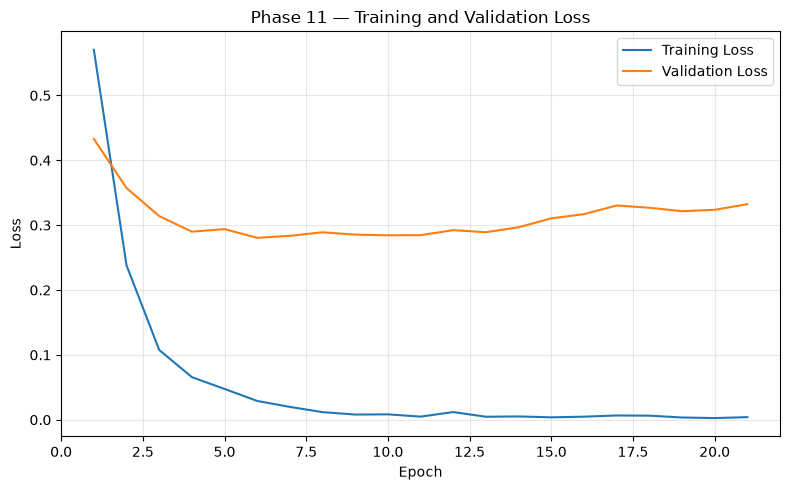

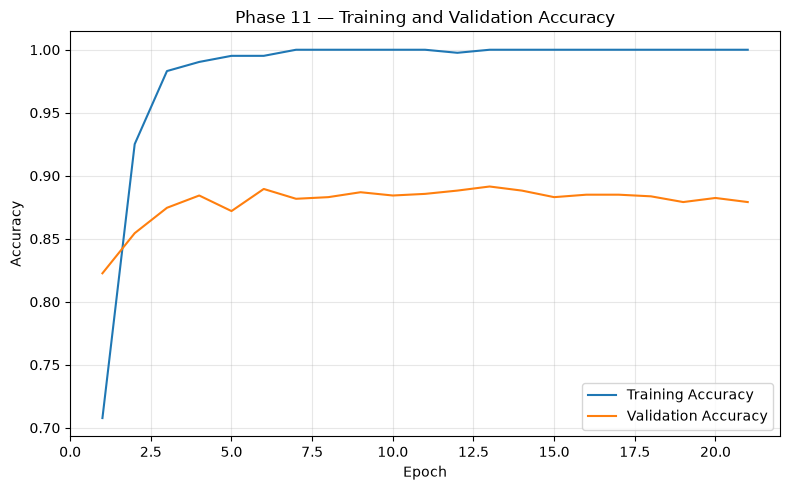

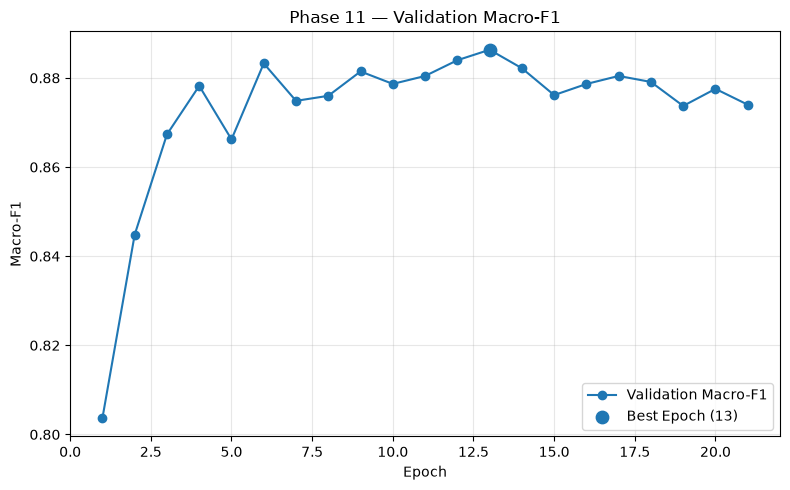

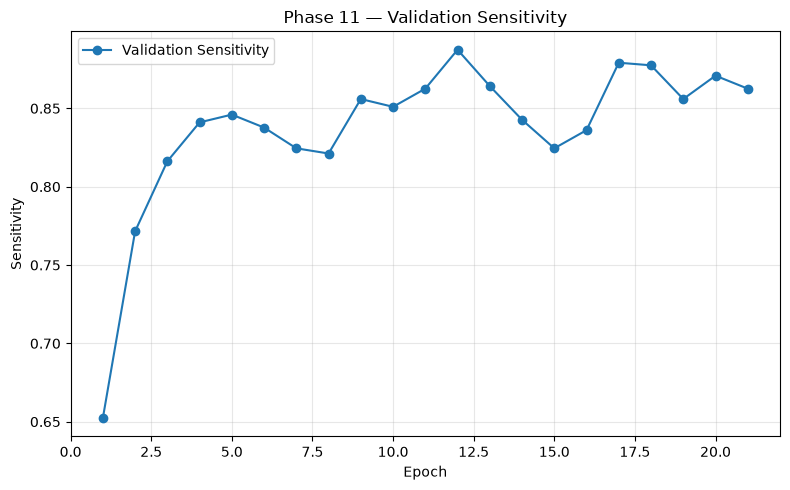

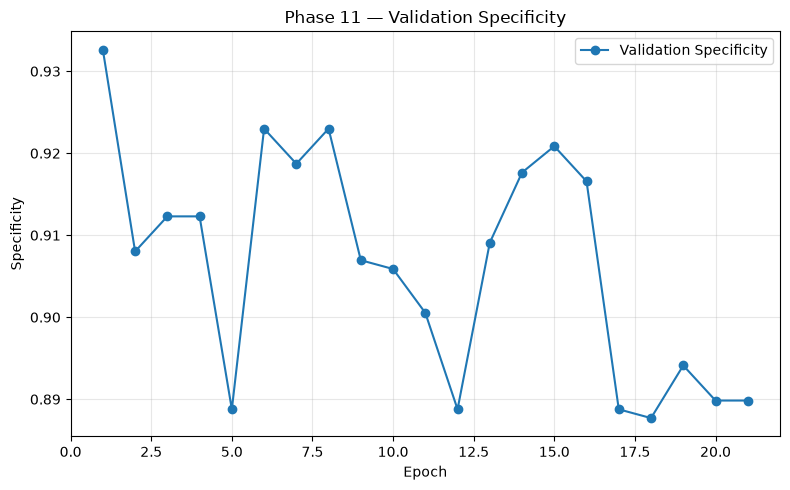


Saved training curves:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\loss_curve.png
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\accuracy_curve.png
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\macro_f1_curve.png
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\sensitivity_curve.png
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\specificity_curve.png

=== PHASE 11 STEP 8 COMPLETE ===


In [99]:
# ============================================================
# PHASE 11 — STEP 8
# GENERATE TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt


print("=" * 60)
print("PHASE 11 — GENERATING TRAINING CURVES")
print("=" * 60)


epochs = history_df["epoch"]


# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["train_loss"],
    label="Training Loss",
)

plt.plot(
    epochs,
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Phase 11 — Training and Validation Loss"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["train_accuracy"],
    label="Training Accuracy",
)

plt.plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Phase 11 — Training and Validation Accuracy"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    ACCURACY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# MACRO-F1 CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1",
)

best_epoch = training_result["best_epoch"]

best_macro_f1 = history_df.loc[
    history_df["epoch"] == best_epoch,
    "val_macro_f1",
].iloc[0]

plt.scatter(
    [best_epoch],
    [best_macro_f1],
    s=80,
    label=f"Best Epoch ({best_epoch})",
)

plt.xlabel("Epoch")

plt.ylabel("Macro-F1")

plt.title(
    "Phase 11 — Validation Macro-F1"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    MACRO_F1_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# SENSITIVITY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_sensitivity"],
    marker="o",
    label="Validation Sensitivity",
)

plt.xlabel("Epoch")

plt.ylabel("Sensitivity")

plt.title(
    "Phase 11 — Validation Sensitivity"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    SENSITIVITY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# SPECIFICITY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_specificity"],
    marker="o",
    label="Validation Specificity",
)

plt.xlabel("Epoch")

plt.ylabel("Specificity")

plt.title(
    "Phase 11 — Validation Specificity"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    SPECIFICITY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


print("\nSaved training curves:")

print(LOSS_CURVE_PATH)
print(ACCURACY_CURVE_PATH)
print(MACRO_F1_CURVE_PATH)
print(SENSITIVITY_CURVE_PATH)
print(SPECIFICITY_CURVE_PATH)

print(
    "\n=== PHASE 11 STEP 8 COMPLETE ==="
)

PHASE 11 — GENERATING TEST SET PLOTS


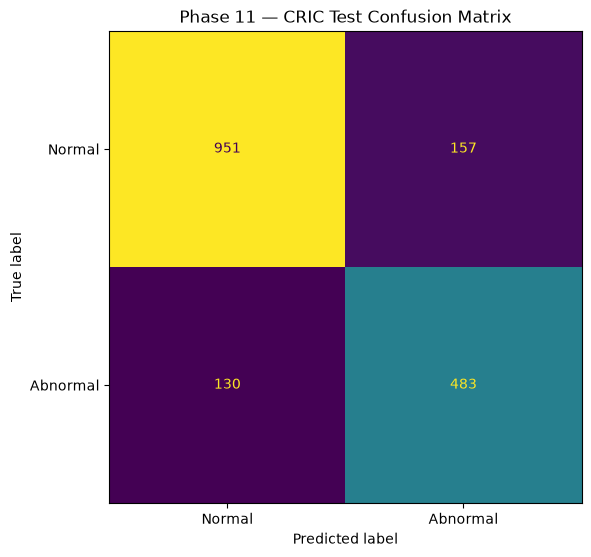

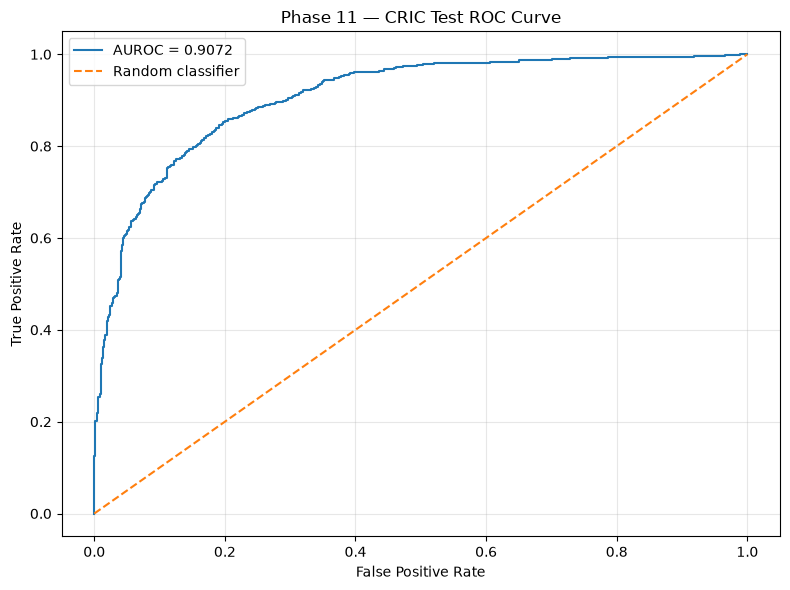


Confusion matrix:
[[951 157]
 [130 483]]

ROC AUROC: 0.9072

Saved test plots:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\confusion_matrix.png
c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\curves\roc_curve.png

=== PHASE 11 STEP 9 COMPLETE ===


In [100]:
# ============================================================
# PHASE 11 — STEP 9
# GENERATE CONFUSION MATRIX + ROC CURVE
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)


print("=" * 60)
print("PHASE 11 — GENERATING TEST SET PLOTS")
print("=" * 60)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1],
)


fig, ax = plt.subplots(
    figsize=(6, 6)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Abnormal",
    ],
)

display_cm.plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "Phase 11 — CRIC Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob,
)

roc_auc = auc(
    fpr,
    tpr,
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUROC = {roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Phase 11 — CRIC Test ROC Curve"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


print("\nConfusion matrix:")
print(cm)

print(
    "\nROC AUROC:",
    f"{roc_auc:.4f}"
)

print("\nSaved test plots:")

print(
    CONFUSION_MATRIX_PATH
)

print(
    ROC_CURVE_PATH
)

print(
    "\n=== PHASE 11 STEP 9 COMPLETE ==="
)

In [101]:
# ============================================================
# PHASE 11 — STEP 10
# FINAL EXPERIMENT ARTIFACT AUDIT
# ============================================================

print("=" * 60)
print("PHASE 11 — FINAL ARTIFACT AUDIT")
print("=" * 60)


required_files = {
    "Labeled subset CSV":
        LABELED_SUBSET_PATH,

    "Training history CSV":
        TRAINING_HISTORY_CSV,

    "Training history PKL":
        TRAINING_HISTORY_PKL,

    "Test results CSV":
        TEST_RESULTS_CSV,

    "Test results PKL":
        TEST_RESULTS_PKL,

    "Test predictions CSV":
        TEST_PREDICTIONS_CSV,

    "Experiment config JSON":
        EXPERIMENT_CONFIG_JSON,

    "Best model checkpoint":
        CHECKPOINT_PATH,

    "Loss curve":
        LOSS_CURVE_PATH,

    "Accuracy curve":
        ACCURACY_CURVE_PATH,

    "Macro-F1 curve":
        MACRO_F1_CURVE_PATH,

    "Sensitivity curve":
        SENSITIVITY_CURVE_PATH,

    "Specificity curve":
        SPECIFICITY_CURVE_PATH,

    "Confusion matrix":
        CONFUSION_MATRIX_PATH,

    "ROC curve":
        ROC_CURVE_PATH,
}


print("\nArtifact verification:\n")


all_present = True


for name, path in required_files.items():

    exists = path.exists()

    status = "✓" if exists else "✗"

    print(
        f"{status} {name}: {path}"
    )

    if not exists:
        all_present = False


print("\n" + "=" * 60)

if all_present:

    print(
        "✓ ALL PHASE 11 ARTIFACTS ARE PRESENT"
    )

else:

    print(
        "✗ SOME PHASE 11 ARTIFACTS ARE MISSING"
    )

print("=" * 60)


# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

print("\nFINAL CRIC TEST METRICS")

print(
    f"Accuracy    : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision   : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Sensitivity : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"Specificity : "
    f"{test_metrics['specificity']:.4f}"
)

print(
    f"Macro-F1    : "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"AUROC       : "
    f"{test_metrics['auroc']:.4f}"
)


print("\nExperiment directory:")
print(RESULTS_DIR)

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

print(
    "\n=== PHASE 11 COMPLETE ==="
)

PHASE 11 — FINAL ARTIFACT AUDIT

Artifact verification:

✓ Labeled subset CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\labeled_subset.csv
✓ Training history CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\training_history.csv
✓ Training history PKL: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\training_history.pkl
✓ Test results CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_results.csv
✓ Test results PKL: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_results.pkl
✓ Test predictions CSV: c:\Users\nanda\Documents\cervical-semi-sl\data\results\experiments\cric_supervised_5pct_densenet121_seed42\test_predictions.csv
✓ Experiment config JSON: c:\Users\nanda\Documents\